In [4]:
# ── IMPORTS ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling — makes all plots look clean
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded ✓")

Libraries loaded ✓


In [5]:
df = pd.read_csv("Telco_customer_churn.csv")

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape: (7043, 33)

Column names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [6]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
print("=== NULL VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== TARGET DISTRIBUTION ===")
print(df['Churn Label'].value_counts())
print(df['Churn Label'].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

=== NULL VALUES ===
Churn Reason    5174
dtype: int64

=== DATA TYPES ===
CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges            str
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int6

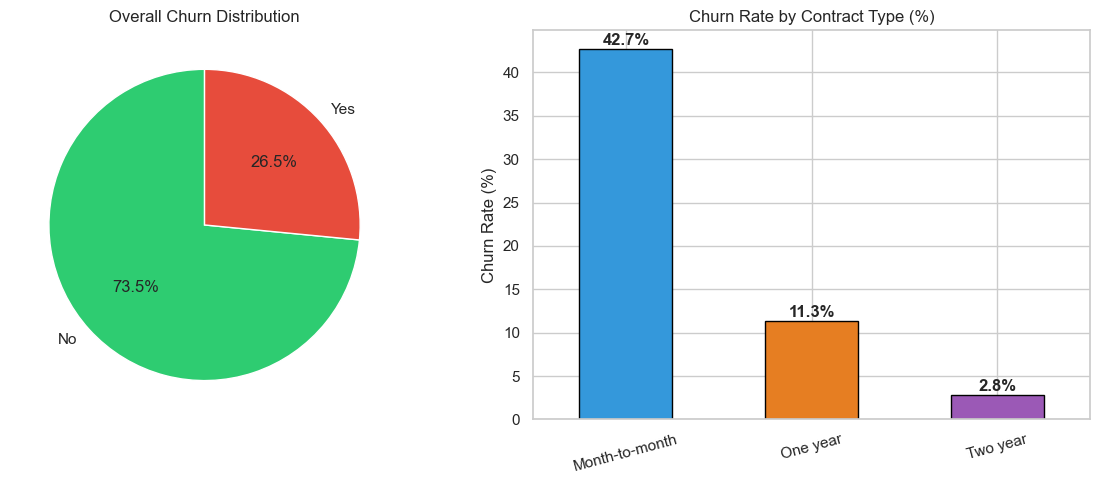

Key insight: Month-to-month customers churn at what rate vs Two year?
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn Value, dtype: float64


In [8]:
# ── 2.1 CHURN RATE OVERVIEW ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
churn_counts = df['Churn Label'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Overall Churn Distribution')

# Churn by Contract Type
churn_by_contract = df.groupby('Contract')['Churn Value'].mean().mul(100).round(1)
churn_by_contract.plot(kind='bar', ax=axes[1], color=['#3498db','#e67e22','#9b59b6'],
                       edgecolor='black')
axes[1].set_title('Churn Rate by Contract Type (%)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

# Add value labels on bars
for i, v in enumerate(churn_by_contract):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Key insight: Month-to-month customers churn at what rate vs Two year?")
print(churn_by_contract)

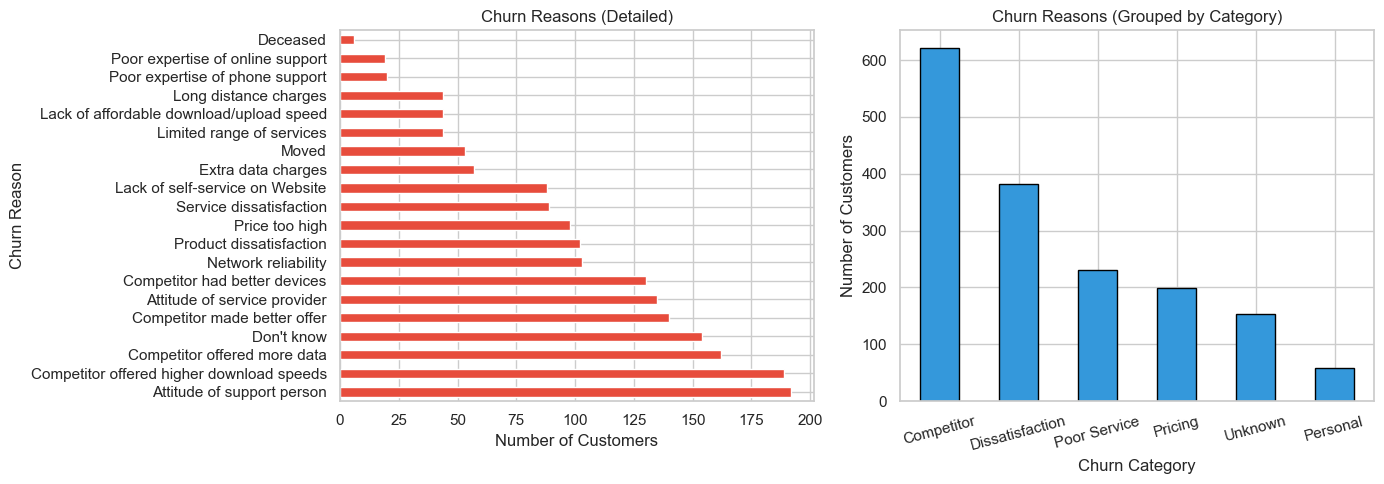


Churn by category:
Churn Category
Competitor         621
Dissatisfaction    382
Poor Service       231
Pricing            199
Unknown            154
Personal            59
Name: count, dtype: int64


In [9]:
# ── 2.2 CHURN REASONS ────────────────────────────────────
# Only churned customers have a churn reason
churned = df[df['Churn Label'] == 'Yes'].copy()

# Group reasons into business categories
reason_map = {
    'Competitor had better devices': 'Competitor',
    'Competitor made better offer': 'Competitor',
    'Competitor offered higher download speeds': 'Competitor',
    'Competitor offered more data': 'Competitor',
    'Attitude of support person': 'Poor Service',
    'Attitude of device repair person': 'Poor Service',
    'Poor expertise of online support': 'Poor Service',
    'Poor expertise of phone support': 'Poor Service',
    'Don\'t know': 'Unknown',
    'Extra data charges': 'Pricing',
    'Long distance charges': 'Pricing',
    'Price too high': 'Pricing',
    'Network reliability': 'Dissatisfaction',
    'Product dissatisfaction': 'Dissatisfaction',
    'Service dissatisfaction': 'Dissatisfaction',
    'Lack of affordable download/upload speed': 'Dissatisfaction',
    'Limited range of services': 'Dissatisfaction',
    'Moved': 'Personal',
    'Deceased': 'Personal',
    'Other': 'Unknown'
}

churned['Churn Category'] = churned['Churn Reason'].map(reason_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All reasons
churned['Churn Reason'].value_counts().plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Churn Reasons (Detailed)')
axes[0].set_xlabel('Number of Customers')

# Grouped categories
churned['Churn Category'].value_counts().plot(kind='bar', ax=axes[1], color='#3498db',
                                               edgecolor='black')
axes[1].set_title('Churn Reasons (Grouped by Category)')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\nChurn by category:")
print(churned['Churn Category'].value_counts())

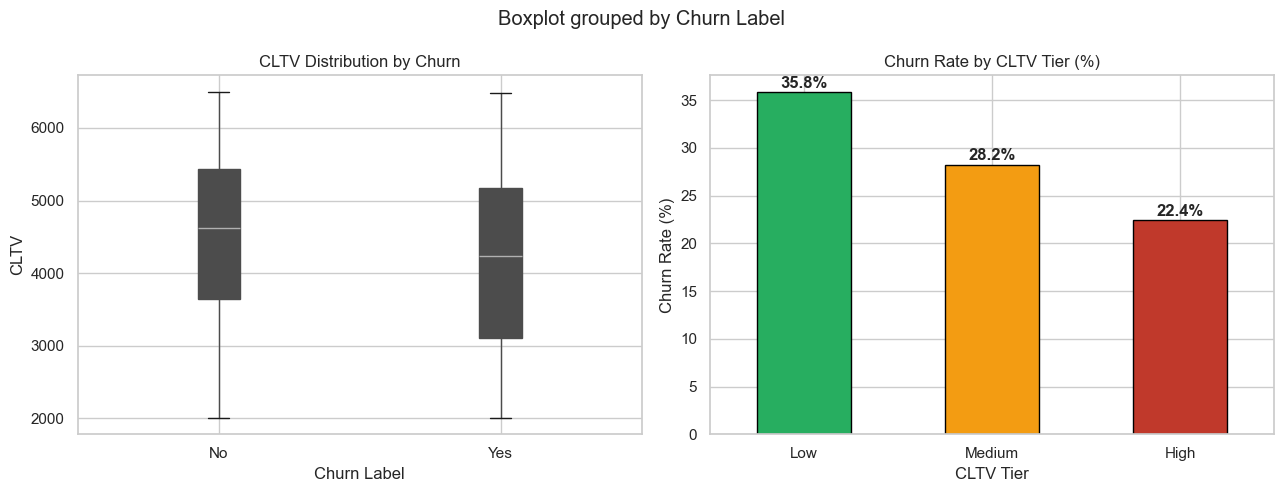


Churn rate by CLTV tier:
CLTV Tier
Low       35.8
Medium    28.2
High      22.4
Name: Churn Value, dtype: float64


In [10]:
# ── 2.3 CLTV (Customer Lifetime Value) ANALYSIS ──────────
# CLTV = how much revenue a customer is expected to generate
# High CLTV churners = biggest business loss

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CLTV distribution by churn
df.boxplot(column='CLTV', by='Churn Label', ax=axes[0],
           patch_artist=True)
axes[0].set_title('CLTV Distribution by Churn')
axes[0].set_xlabel('Churn Label')
axes[0].set_ylabel('CLTV')
plt.sca(axes[0])
plt.title('CLTV Distribution by Churn')

# Create CLTV tiers
df['CLTV Tier'] = pd.cut(df['CLTV'],
                          bins=[0, 3000, 4500, 6500],
                          labels=['Low', 'Medium', 'High'])

churn_by_cltv = df.groupby('CLTV Tier', observed=True)['Churn Value'].mean().mul(100).round(1)
churn_by_cltv.plot(kind='bar', ax=axes[1], color=['#27ae60','#f39c12','#c0392b'],
                   edgecolor='black')
axes[1].set_title('Churn Rate by CLTV Tier (%)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(churn_by_cltv):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nChurn rate by CLTV tier:")
print(churn_by_cltv)

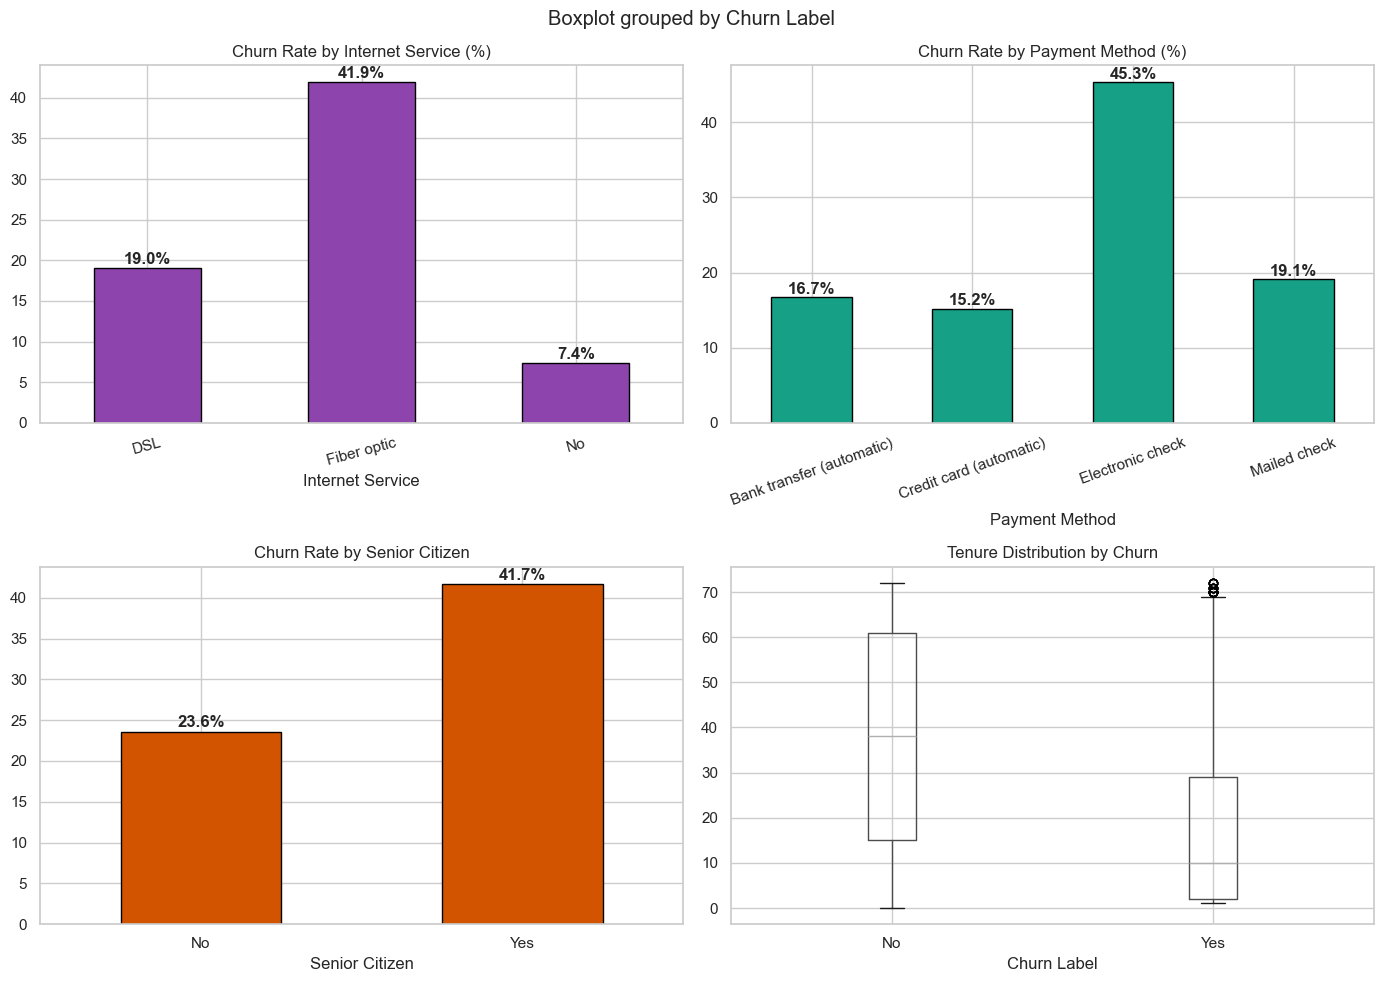

In [11]:
# ── 2.4 SERVICE & DEMOGRAPHIC PATTERNS ───────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Churn by Internet Service
churn_internet = df.groupby('Internet Service')['Churn Value'].mean().mul(100).round(1)
churn_internet.plot(kind='bar', ax=axes[0,0], color='#8e44ad', edgecolor='black')
axes[0,0].set_title('Churn Rate by Internet Service (%)')
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(churn_internet):
    axes[0,0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Churn by Payment Method
churn_payment = df.groupby('Payment Method')['Churn Value'].mean().mul(100).round(1)
churn_payment.plot(kind='bar', ax=axes[0,1], color='#16a085', edgecolor='black')
axes[0,1].set_title('Churn Rate by Payment Method (%)')
axes[0,1].tick_params(axis='x', rotation=20)
for i, v in enumerate(churn_payment):
    axes[0,1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Churn by Senior Citizen
churn_senior = df.groupby('Senior Citizen')['Churn Value'].mean().mul(100).round(1)
churn_senior.plot(kind='bar', ax=axes[1,0], color='#d35400', edgecolor='black')
axes[1,0].set_title('Churn Rate by Senior Citizen')
axes[1,0].tick_params(axis='x', rotation=0)
for i, v in enumerate(churn_senior):
    axes[1,0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Tenure vs Churn
df.boxplot(column='Tenure Months', by='Churn Label', ax=axes[1,1])
axes[1,1].set_title('Tenure Distribution by Churn')
axes[1,1].set_xlabel('Churn Label')
plt.sca(axes[1,1])
plt.title('Tenure Distribution by Churn')

plt.tight_layout()
plt.show()

In [12]:
# ── 3.1 SEPARATE COLUMNS ─────────────────────────────────

# Save these SEPARATELY - we'll use them AFTER modeling for segmentation
# Don't drop them from df yet, just note them
business_cols = ['CustomerID', 'CLTV', 'Churn Reason', 'Churn Score']

# Columns to DROP from modeling - useless for prediction
# (IDs, geography, redundant columns)
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City',
    'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Label',   # we'll use Churn Value (0/1) as target instead
    'Churn Score',   # this IS churn risk score - using it would be cheating
    'Churn Reason',  # only available after churn happens - can't use for prediction
]

print("Columns we'll drop from model:", drop_cols)
print("\nColumns we're KEEPING for segmentation after modeling:")
print(business_cols)

Columns we'll drop from model: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'Churn Reason']

Columns we're KEEPING for segmentation after modeling:
['CustomerID', 'CLTV', 'Churn Reason', 'Churn Score']


In [13]:
# ── 3.2 FIX DATA TYPES ───────────────────────────────────

# Save business columns before we start modifying
df_business = df[business_cols].copy()

# Fix Total Charges - convert from string to number
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# The 11 nulls are customers with Tenure=0 (never been billed)
# Fill with 0 - makes sense, they've paid nothing yet
df['Total Charges'] = df['Total Charges'].fillna(0)

print("Total Charges nulls after fix:", df['Total Charges'].isnull().sum())
print("Total Charges dtype:", df['Total Charges'].dtype)
print("\nSample - Tenure 0 customers:")
print(df[df['Tenure Months'] == 0][['Tenure Months', 'Monthly Charges', 'Total Charges']].head(3))


Total Charges nulls after fix: 0
Total Charges dtype: float64

Sample - Tenure 0 customers:
      Tenure Months  Monthly Charges  Total Charges
2234              0            52.55            0.0
2438              0            20.25            0.0
2568              0            80.85            0.0


In [14]:
# ── 3.3 FEATURE ENGINEERING ──────────────────────────────

# 1. Tenure Group - instead of raw number 0-72, group into stages
df['Tenure Group'] = pd.cut(
    df['Tenure Months'],
    bins=[0, 12, 36, 72],
    labels=['New', 'Mid', 'Loyal'],
    include_lowest=True
)

# 2. Number of services subscribed
# Count how many add-on services each customer has
service_cols = ['Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies']

df['Service Count'] = df[service_cols].apply(
    lambda row: sum(1 for val in row if val == 'Yes'), axis=1
)

# 3. Average monthly spend per tenure month
# High spender who just joined = different risk than long-term high spender
df['Charges Per Month'] = df['Monthly Charges'] / (df['Tenure Months'] + 1)

print("=== New Features Sample ===")
print(df[['Tenure Months', 'Tenure Group', 'Service Count',
          'Monthly Charges', 'Charges Per Month']].head(10))

print("\nTenure Group distribution:")
print(df['Tenure Group'].value_counts())

print("\nService Count distribution:")
print(df['Service Count'].value_counts().sort_index())

=== New Features Sample ===
   Tenure Months Tenure Group  Service Count  Monthly Charges  \
0              2          New              2            53.85   
1              2          New              0            70.70   
2              8          New              3            99.65   
3             28          Mid              4           104.80   
4             49        Loyal              4           103.70   
5             10          New              2            55.20   
6              1          New              2            39.65   
7              1          New              0            20.15   
8             47        Loyal              3            99.35   
9              1          New              1            30.20   

   Charges Per Month  
0          17.950000  
1          23.566667  
2          11.072222  
3           3.613793  
4           2.074000  
5           5.018182  
6          19.825000  
7          10.075000  
8           2.069792  
9          15.100000  

Te

In [15]:
# ── 3.4 PREPARE MODELING DATA ────────────────────────────

# Create modeling dataframe - drop the columns we don't need
df_model = df.drop(columns=drop_cols)

# Separate target
X = df_model.drop(columns=['Churn Value'])
y = df_model['Churn Value']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 24)
Target shape: (7043,)

Feature columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV', 'CLTV Tier', 'Tenure Group', 'Service Count', 'Charges Per Month']

Target distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64


In [16]:
# ── 3.5 ENCODE CATEGORICAL COLUMNS ───────────────────────
from sklearn.preprocessing import LabelEncoder

# Binary columns (Yes/No) - simple label encoding
binary_cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Paperless Billing'
]

le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])

# Multi-category columns - one hot encoding
# drop_first=True avoids multicollinearity
multi_cols = [
    'Multiple Lines', 'Internet Service', 'Online Security',
    'Online Backup', 'Device Protection', 'Tech Support',
    'Streaming TV', 'Streaming Movies', 'Contract',
    'Payment Method', 'Tenure Group'
]

X = pd.get_dummies(X, columns=multi_cols, drop_first=True)

print("Shape after encoding:", X.shape)
print("\nAll columns now numeric:")
print(X.dtypes.unique())
print("\nSample columns:")
print(X.columns.tolist()[:15])

Shape after encoding: (7043, 36)

All columns now numeric:
[dtype('int64') dtype('float64')
 CategoricalDtype(categories=['Low', 'Medium', 'High'], ordered=True, categories_dtype=str)
 dtype('bool')]

Sample columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'CLTV', 'CLTV Tier', 'Service Count', 'Charges Per Month', 'Multiple Lines_No phone service', 'Multiple Lines_Yes']


In [17]:
# ── 3.6 TRAIN TEST SPLIT ─────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # same split every time you run
    stratify=y           # keeps same 73/27 ratio in both splits
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTarget distribution in train:")
print(y_train.value_counts(normalize=True).mul(100).round(1))
print("\nTarget distribution in test:")
print(y_test.value_counts(normalize=True).mul(100).round(1))

Training set: (5634, 36)
Test set: (1409, 36)

Target distribution in train:
Churn Value
0    73.5
1    26.5
Name: proportion, dtype: float64

Target distribution in test:
Churn Value
0    73.5
1    26.5
Name: proportion, dtype: float64


In [18]:
# ── 3.7 SCALE NUMERICAL FEATURES ─────────────────────────
from sklearn.preprocessing import StandardScaler

# These are the columns with large numeric ranges
scale_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges',
              'CLTV', 'Churn Score', 'Service Count', 'Charges Per Month']

# Only scale columns that actually exist in X after encoding
scale_cols = [col for col in scale_cols if col in X_train.columns]

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

# Save scaler - we need it for the Streamlit app later
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(scale_cols, 'scale_cols.pkl')

print("Scaling done ✓")
print("Scaled columns:", scale_cols)
print("\nSample scaled values:")
print(X_train[scale_cols].head(3).round(3))

Scaling done ✓
Scaled columns: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Service Count', 'Charges Per Month']

Sample scaled values:
      Tenure Months  Monthly Charges  Total Charges   CLTV  Service Count  \
4626          0.102           -0.522         -0.262 -1.372          0.508   
4192         -0.712            0.337         -0.504  0.194         -0.571   
5457         -0.793           -0.809         -0.750 -1.274          0.508   

      Charges Per Month  
4626             -0.502  
4192             -0.119  
5457             -0.326  


In [19]:
# ── 4.1 TRAIN ALL MODELS ─────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

# Define all models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', random_state=42),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=42),

    'XGBoost': XGBClassifier(
        n_estimators=100, scale_pos_weight=3,
        eval_metric='logloss', random_state=42)
}

# class_weight='balanced' and scale_pos_weight=3 both handle class imbalance
# They tell the model: pay more attention to the minority class (churners)

print("Models defined ✓")
print("Training now — XGBoost may take ~30 seconds...")

Models defined ✓
Training now — XGBoost may take ~30 seconds...


In [20]:
# ── FIX: Convert Tenure Group to numeric ─────────────────

# Check what non-numeric columns are still left
non_numeric = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Non-numeric columns still in X_train:", non_numeric)

# Encode any remaining categorical columns
if len(non_numeric) > 0:
    X_train = pd.get_dummies(X_train, columns=non_numeric, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=non_numeric, drop_first=True)
    
    # Make sure both have same columns after encoding
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
    
    print("Fixed ✓")
    print("New shape:", X_train.shape)
else:
    print("No issues found ✓")

Non-numeric columns still in X_train: ['CLTV Tier']
Fixed ✓
New shape: (5634, 37)


In [21]:
# ── 4.2 EVALUATE ALL MODELS ──────────────────────────────

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred) * 100, 1),
        'Precision': round(precision_score(y_test, y_pred) * 100, 1),
        'Recall': round(recall_score(y_test, y_pred) * 100, 1),
        'F1 Score': round(f1_score(y_test, y_pred) * 100, 1),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob) * 100, 1)
    })

    print(f"{name} ✓")

# Make comparison table
results_df = pd.DataFrame(results).set_index('Model')
print("\n=== MODEL COMPARISON TABLE ===")
print(results_df.to_string())

Logistic Regression ✓
Decision Tree ✓
Random Forest ✓
Gradient Boosting ✓
XGBoost ✓

=== MODEL COMPARISON TABLE ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression      75.4       52.4    78.9      63.0     85.3
Decision Tree            73.5       50.0    49.2      49.6     65.7
Random Forest            79.6       65.5    48.7      55.8     83.8
Gradient Boosting        80.4       65.9    54.3      59.5     85.3
XGBoost                  77.5       56.1    70.1      62.3     83.6


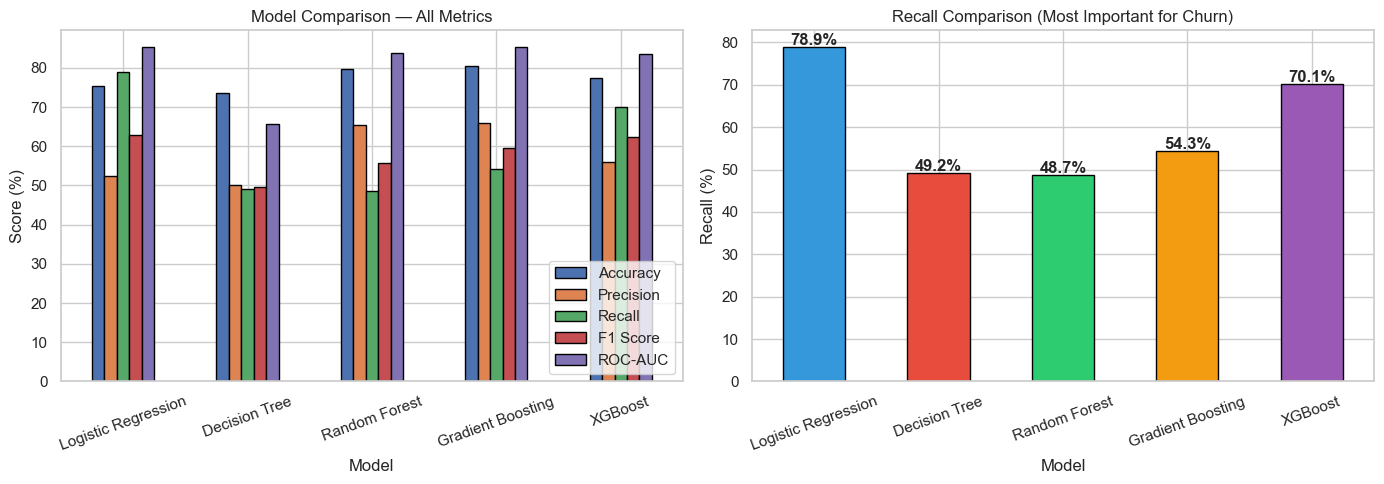


Best model by Recall: Logistic Regression
Best model by F1: Logistic Regression
Best model by ROC-AUC: Logistic Regression


In [22]:
# ── 4.3 VISUALIZE MODEL COMPARISON ───────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All metrics comparison
results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']].plot(
    kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Model Comparison — All Metrics')
axes[0].set_ylabel('Score (%)')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(loc='lower right')

# Recall specifically - most important for churn
results_df['Recall'].plot(
    kind='bar', ax=axes[1],
    color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'],
    edgecolor='black')
axes[1].set_title('Recall Comparison (Most Important for Churn)')
axes[1].set_ylabel('Recall (%)')
axes[1].tick_params(axis='x', rotation=20)

# Add value labels
for i, v in enumerate(results_df['Recall']):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nBest model by Recall:", results_df['Recall'].idxmax())
print("Best model by F1:", results_df['F1 Score'].idxmax())
print("Best model by ROC-AUC:", results_df['ROC-AUC'].idxmax())

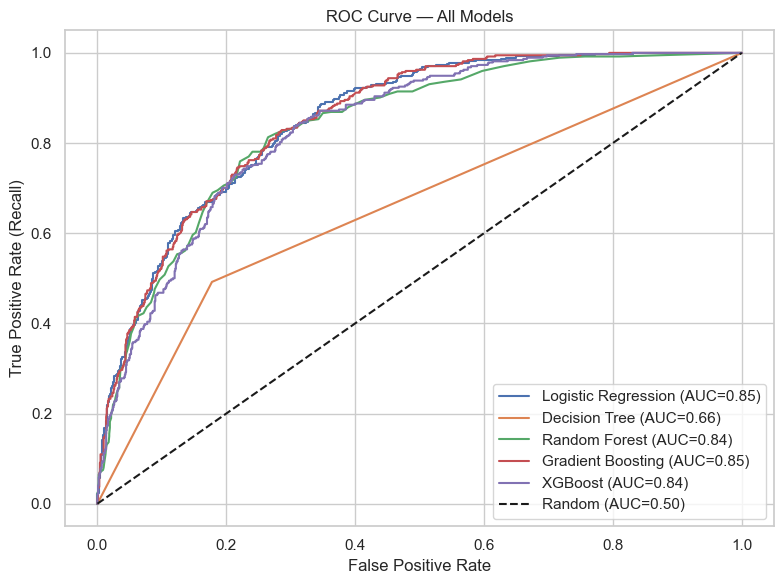

In [23]:
# ── 4.4 ROC CURVE ────────────────────────────────────────
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--', label='Random (AUC=0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [24]:
# ── 5.1 HYPERPARAMETER TUNING ─────────────────────────────
from sklearn.model_selection import GridSearchCV

# Focused parameter grid - not too large, runs in ~5-10 mins
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=3,
    eval_metric='logloss',
    random_state=42
)

# cv=5 means 5-fold cross validation
# scoring='recall' because recall is our priority
grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,        # use all CPU cores - speeds it up
    verbose=1
)

print("Starting GridSearchCV... this will take a few minutes")
grid_search.fit(X_train, y_train)

print("\n=== BEST PARAMETERS ===")
print(grid_search.best_params_)
print("\nBest cross-validation recall:", round(grid_search.best_score_ * 100, 1), "%")

Starting GridSearchCV... this will take a few minutes
Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== BEST PARAMETERS ===
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}

Best cross-validation recall: 84.5 %


In [25]:
# ── 5.2 EVALUATE TUNED MODEL ──────────────────────────────

best_xgb = grid_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("=== TUNED XGBoost PERFORMANCE (default threshold 0.5) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned)*100:.1f}%")
print(f"Precision: {precision_score(y_test, y_pred_tuned)*100:.1f}%")
print(f"Recall:    {recall_score(y_test, y_pred_tuned)*100:.1f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred_tuned)*100:.1f}%")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned)*100:.1f}%")

# Compare with untuned
print("\n=== COMPARISON: Untuned vs Tuned ===")
compare = pd.DataFrame({
    'Untuned XGBoost': results_df.loc['XGBoost'],
    'Tuned XGBoost': {
        'Accuracy': round(accuracy_score(y_test, y_pred_tuned)*100, 1),
        'Precision': round(precision_score(y_test, y_pred_tuned)*100, 1),
        'Recall': round(recall_score(y_test, y_pred_tuned)*100, 1),
        'F1 Score': round(f1_score(y_test, y_pred_tuned)*100, 1),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob_tuned)*100, 1)
    }
})
print(compare)

=== TUNED XGBoost PERFORMANCE (default threshold 0.5) ===
Accuracy:  73.6%
Precision: 50.2%
Recall:    82.9%
F1 Score:  62.5%
ROC-AUC:   85.2%

=== COMPARISON: Untuned vs Tuned ===
           Untuned XGBoost  Tuned XGBoost
Accuracy              77.5           73.6
Precision             56.1           50.2
Recall                70.1           82.9
F1 Score              62.3           62.5
ROC-AUC               83.6           85.2


In [26]:
# ── 5.3 THRESHOLD TUNING ──────────────────────────────────
import numpy as np

thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_prob_tuned >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Precision': round(precision_score(y_test, y_pred_t)*100, 1),
        'Recall': round(recall_score(y_test, y_pred_t)*100, 1),
        'F1 Score': round(f1_score(y_test, y_pred_t)*100, 1)
    })

thresh_df = pd.DataFrame(threshold_results).set_index('Threshold')
print("=== THRESHOLD ANALYSIS ===")
print(thresh_df.to_string())

=== THRESHOLD ANALYSIS ===
           Precision  Recall  F1 Score
Threshold                             
0.10            34.1    99.5      50.8
0.15            37.6    98.1      54.4
0.20            39.4    97.1      56.1
0.25            41.6    96.0      58.0
0.30            43.3    93.9      59.3
0.35            45.1    91.4      60.4
0.40            46.4    88.2      60.8
0.45            47.8    85.6      61.3
0.50            50.2    82.9      62.5
0.55            52.6    79.9      63.5
0.60            53.8    72.7      61.8
0.65            58.5    66.6      62.3
0.70            62.5    58.8      60.6
0.75            68.2    50.5      58.1
0.80            70.7    37.4      49.0
0.85            75.0    25.7      38.2


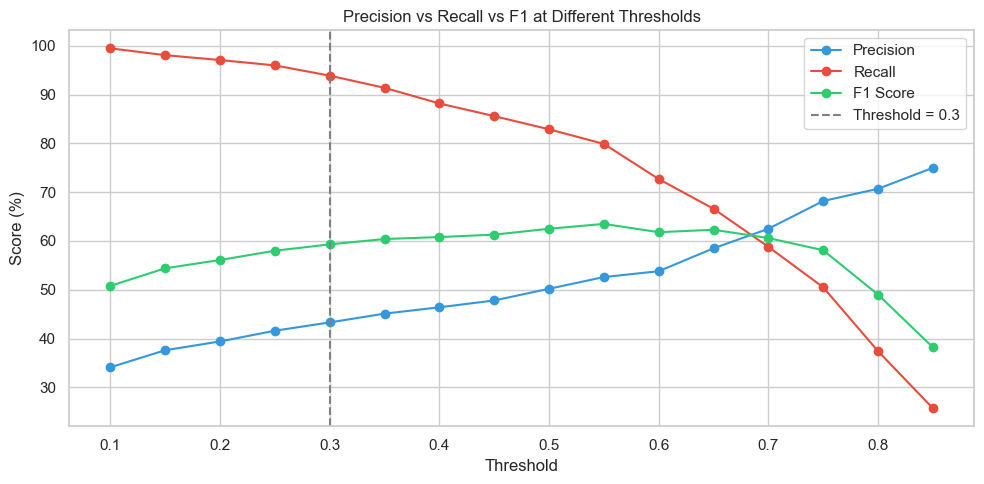

Best threshold by F1:     0.55
Best threshold by Recall: 0.1

=== FINAL MODEL METRICS at threshold 0.55 ===
Precision: 52.6%
Recall:    79.9%
F1 Score:  63.5%


In [27]:
# ── 5.4 VISUALIZE & PICK BEST THRESHOLD ───────────────────

plt.figure(figsize=(10, 5))
plt.plot(thresh_df.index, thresh_df['Precision'], 
         label='Precision', marker='o', color='#3498db')
plt.plot(thresh_df.index, thresh_df['Recall'], 
         label='Recall', marker='o', color='#e74c3c')
plt.plot(thresh_df.index, thresh_df['F1 Score'], 
         label='F1 Score', marker='o', color='#2ecc71')

plt.axvline(x=0.3, color='gray', linestyle='--', label='Threshold = 0.3')
plt.xlabel('Threshold')
plt.ylabel('Score (%)')
plt.title('Precision vs Recall vs F1 at Different Thresholds')
plt.legend()
plt.tight_layout()
plt.show()

# Best threshold = highest F1 (balanced) 
best_threshold = thresh_df['F1 Score'].idxmax()
print(f"Best threshold by F1:     {best_threshold}")
print(f"Best threshold by Recall: {thresh_df['Recall'].idxmax()}")

# Show metrics at best threshold
print(f"\n=== FINAL MODEL METRICS at threshold {best_threshold} ===")
y_pred_final = (y_prob_tuned >= best_threshold).astype(int)
print(f"Precision: {precision_score(y_test, y_pred_final)*100:.1f}%")
print(f"Recall:    {recall_score(y_test, y_pred_final)*100:.1f}%")
print(f"F1 Score:  {f1_score(y_test, y_pred_final)*100:.1f}%")

In [29]:
# ── 5.5 SAVE FINAL MODEL ──────────────────────────────────
import joblib

# Save everything we need for the Streamlit app
joblib.dump(best_xgb, 'churn_model.pkl')
joblib.dump(best_threshold, 'threshold.pkl')

print("Model saved ✓")
print("Threshold saved ✓")
print(f"\nFinal model: Tuned XGBoost")
print(f"Final threshold: {best_threshold}")


Model saved ✓
Threshold saved ✓

Final model: Tuned XGBoost
Final threshold: 0.55


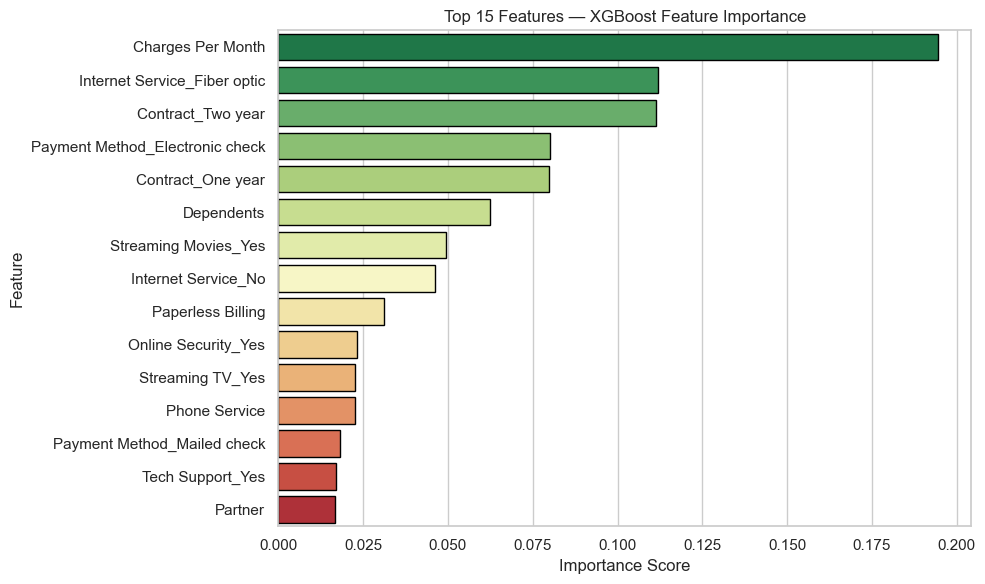

=== TOP 15 FEATURES ===
                        Feature  Importance
              Charges Per Month    0.194524
   Internet Service_Fiber optic    0.112029
              Contract_Two year    0.111298
Payment Method_Electronic check    0.080190
              Contract_One year    0.079928
                     Dependents    0.062380
           Streaming Movies_Yes    0.049320
            Internet Service_No    0.046254
              Paperless Billing    0.031085
            Online Security_Yes    0.023156
               Streaming TV_Yes    0.022708
                  Phone Service    0.022577
    Payment Method_Mailed check    0.018116
               Tech Support_Yes    0.017049
                        Partner    0.016837


In [30]:
# ── 6.1 FEATURE IMPORTANCE ───────────────────────────────

# Get feature importances from tuned XGBoost
feature_names = X_train.columns.tolist()
importances = best_xgb.feature_importances_

# Create sorted dataframe
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature',
            palette='RdYlGn_r', edgecolor='black')
plt.title('Top 15 Features — XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("=== TOP 15 FEATURES ===")
print(feat_imp_df.to_string(index=False))

In [31]:
# ── 6.2 GET CHURN PROBABILITY FOR ALL CUSTOMERS ──────────

# We need to preprocess the full dataset the same way we did for modeling
# Use the same X (before train/test split) but we saved it — reconstruct it

# Get churn probabilities for test set customers
# Merge back with business columns using index
df_segment = df_business.loc[X_test.index].copy()
df_segment['Churn_Probability'] = y_prob_tuned
df_segment['Predicted_Churn'] = (y_prob_tuned >= best_threshold).astype(int)
df_segment['Actual_Churn'] = y_test.values

print("Segment dataframe shape:", df_segment.shape)
print("\nSample:")
print(df_segment.head())
print("\nPredicted churn distribution:")
print(df_segment['Predicted_Churn'].value_counts())

Segment dataframe shape: (1409, 7)

Sample:
      CustomerID  CLTV Churn Reason  Churn Score  Churn_Probability  \
2196  4376-KFVRS  4842          NaN           39           0.119375   
3549  2754-SDJRD  5157          NaN           42           0.876766   
3515  9917-KWRBE  2894          NaN           44           0.286126   
5162  0365-GXEZS  2831          NaN           79           0.723332   
4642  9385-NXKDA  4324          NaN           42           0.068993   

      Predicted_Churn  Actual_Churn  
2196                0             0  
3549                1             0  
3515                0             0  
5162                1             0  
4642                0             0  

Predicted churn distribution:
Predicted_Churn
0    841
1    568
Name: count, dtype: int64


In [32]:
# ── 6.3 CREATE BUSINESS SEGMENTS ─────────────────────────

# CLTV tiers (same as Part 2)
df_segment['CLTV_Tier'] = pd.cut(
    df_segment['CLTV'],
    bins=[0, 3000, 4500, 6500],
    labels=['Low', 'Medium', 'High']
)

# Churn Risk tier based on probability
df_segment['Risk_Level'] = pd.cut(
    df_segment['Churn_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Business segment combining both
def assign_segment(row):
    if row['Risk_Level'] == 'High Risk' and row['CLTV_Tier'] == 'High':
        return 'Priority — Retain Now'
    elif row['Risk_Level'] == 'High Risk' and row['CLTV_Tier'] == 'Medium':
        return 'High Risk — Monitor'
    elif row['Risk_Level'] == 'High Risk' and row['CLTV_Tier'] == 'Low':
        return 'High Risk — Low Value'
    elif row['Risk_Level'] == 'Medium Risk':
        return 'Medium Risk — Engage'
    else:
        return 'Stable — Maintain'

df_segment['Business_Segment'] = df_segment.apply(assign_segment, axis=1)

print("=== SEGMENT DISTRIBUTION ===")
print(df_segment['Business_Segment'].value_counts())
print()
print("=== AVG CLTV PER SEGMENT ===")
print(df_segment.groupby('Business_Segment')['CLTV'].mean().round(0).sort_values(ascending=False))

=== SEGMENT DISTRIBUTION ===
Business_Segment
Stable — Maintain        599
Medium Risk — Engage     304
Priority — Retain Now    198
High Risk — Monitor      178
High Risk — Low Value    130
Name: count, dtype: int64

=== AVG CLTV PER SEGMENT ===
Business_Segment
Priority — Retain Now    5284.0
Stable — Maintain        4657.0
Medium Risk — Engage     4425.0
High Risk — Monitor      3786.0
High Risk — Low Value    2491.0
Name: CLTV, dtype: float64


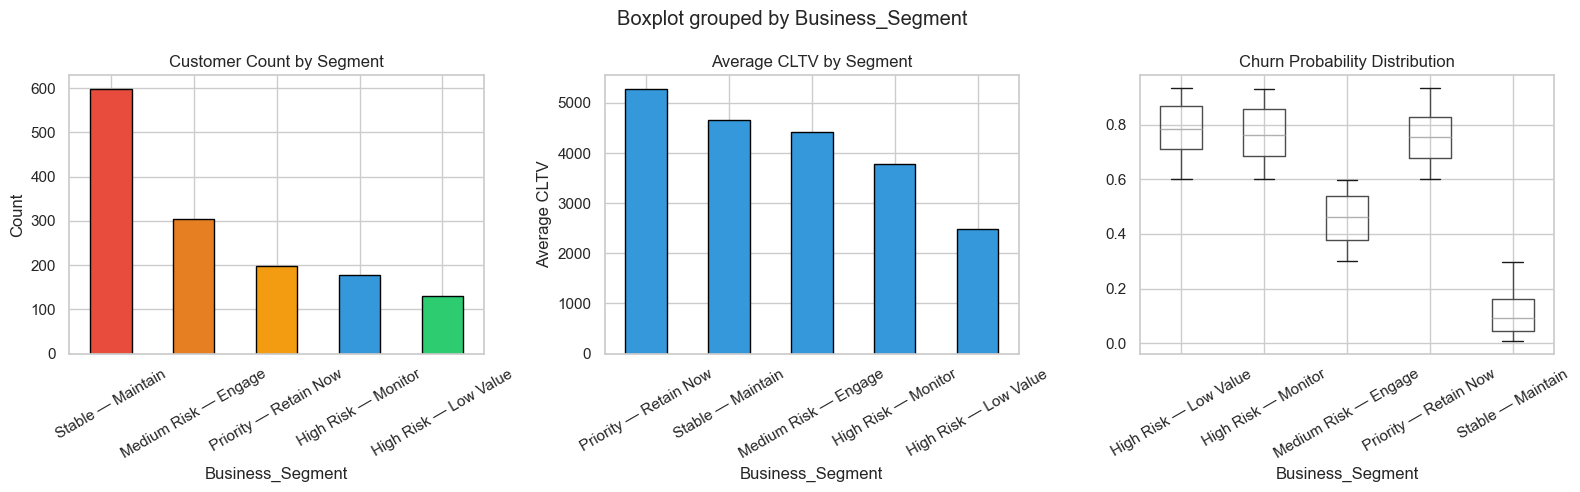

In [33]:
# ── 6.4 VISUALIZE SEGMENTS ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Segment distribution
seg_counts = df_segment['Business_Segment'].value_counts()
colors = ['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#2ecc71']
seg_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Customer Count by Segment')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylabel('Count')

# Average CLTV by segment
cltv_by_seg = df_segment.groupby('Business_Segment')['CLTV'].mean().sort_values(ascending=False)
cltv_by_seg.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Average CLTV by Segment')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylabel('Average CLTV')

# Churn probability distribution by segment
df_segment.boxplot(column='Churn_Probability', by='Business_Segment',
                   ax=axes[2])
axes[2].set_title('Churn Probability by Segment')
axes[2].tick_params(axis='x', rotation=30)
plt.sca(axes[2])
plt.title('Churn Probability Distribution')

plt.tight_layout()
plt.show()

In [34]:
# ── 6.5 BUSINESS RECOMMENDATIONS ─────────────────────────

recommendations = {
    'Priority — Retain Now': {
        'Count': seg_counts.get('Priority — Retain Now', 0),
        'Action': 'Immediate personal outreach + premium discount offer',
        'Why': 'High value + high risk = biggest revenue loss if they leave'
    },
    'High Risk — Monitor': {
        'Count': seg_counts.get('High Risk — Monitor', 0),
        'Action': 'Automated retention email + service upgrade offer',
        'Why': 'Medium value at risk — worth saving with low-cost intervention'
    },
    'High Risk — Low Value': {
        'Count': seg_counts.get('High Risk — Low Value', 0),
        'Action': 'Low-cost retention only (chatbot offer)',
        'Why': 'High risk but low CLTV — not worth expensive retention'
    },
    'Medium Risk — Engage': {
        'Count': seg_counts.get('Medium Risk — Engage', 0),
        'Action': 'Loyalty program enrollment + satisfaction survey',
        'Why': 'Showing early risk signals — engage before risk increases'
    },
    'Stable — Maintain': {
        'Count': seg_counts.get('Stable — Maintain', 0),
        'Action': 'Regular engagement + upsell opportunities',
        'Why': 'Happy customers — focus on expanding their services'
    }
}

rec_df = pd.DataFrame(recommendations).T
print("=== RETENTION STRATEGY BY SEGMENT ===")
print(rec_df.to_string())

=== RETENTION STRATEGY BY SEGMENT ===
                      Count                                                Action                                                             Why
Priority — Retain Now   198  Immediate personal outreach + premium discount offer     High value + high risk = biggest revenue loss if they leave
High Risk — Monitor     178     Automated retention email + service upgrade offer  Medium value at risk — worth saving with low-cost intervention
High Risk — Low Value   130               Low-cost retention only (chatbot offer)          High risk but low CLTV — not worth expensive retention
Medium Risk — Engage    304      Loyalty program enrollment + satisfaction survey       Showing early risk signals — engage before risk increases
Stable — Maintain       599             Regular engagement + upsell opportunities             Happy customers — focus on expanding their services


In [35]:
# ── 6.6 REVENUE AT RISK ───────────────────────────────────
# This is the number that makes business stakeholders pay attention

high_risk = df_segment[df_segment['Predicted_Churn'] == 1]

print("=== REVENUE AT RISK ANALYSIS ===")
print(f"Total customers predicted to churn: {len(high_risk)}")
print(f"Average CLTV of at-risk customers: ${high_risk['CLTV'].mean():.0f}")
print(f"Total CLTV at risk: ${high_risk['CLTV'].sum():,.0f}")
print()

priority = df_segment[df_segment['Business_Segment'] == 'Priority — Retain Now']
print(f"Priority segment (High Risk + High CLTV):")
print(f"  Customers: {len(priority)}")
print(f"  Total CLTV at risk: ${priority['CLTV'].sum():,.0f}")
print(f"  Average churn probability: {priority['Churn_Probability'].mean():.1%}")
print()
print("Key insight: Retaining even 30% of Priority segment saves $",
      round(priority['CLTV'].sum() * 0.3, 0), "in customer lifetime value")

=== REVENUE AT RISK ANALYSIS ===
Total customers predicted to churn: 568
Average CLTV of at-risk customers: $4059
Total CLTV at risk: $2,305,347

Priority segment (High Risk + High CLTV):
  Customers: 198
  Total CLTV at risk: $1,046,197
  Average churn probability: 75.6%

Key insight: Retaining even 30% of Priority segment saves $ 313859.0 in customer lifetime value


In [48]:
# ── 7.1 LOAD CHURN DATA INTO SQL DATABASE ────────────────
import sqlite3
import pandas as pd

# Load fresh data
df_sql = pd.read_csv("Telco_customer_churn.csv")

In [49]:
# Fix Total Charges
df_sql['Total Charges'] = pd.to_numeric(df_sql['Total Charges'], errors='coerce').fillna(0)

# Clean column names for SQL (remove spaces)
df_sql.columns = df_sql.columns.str.replace(' ', '_')

# Create in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Load dataframe into SQL as a table called 'customers'
df_sql.to_sql('customers', conn, index=False, if_exists='replace')

print("Database created ✓")
print("Table 'customers' loaded with", len(df_sql), "rows")
print("\nColumns available in SQL:")
print(df_sql.columns.tolist())

Database created ✓
Table 'customers' loaded with 7043 rows

Columns available in SQL:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code', 'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value', 'Churn_Score', 'CLTV', 'Churn_Reason']


In [50]:
# ── QUERY 1: Churn rate by contract type ─────────────────
query1 = """
SELECT 
    Contract,
    COUNT(*) as Total_Customers,
    SUM(Churn_Value) as Churned_Customers,
    ROUND(AVG(Churn_Value) * 100, 1) as Churn_Rate_Pct
FROM customers
GROUP BY Contract
ORDER BY Churn_Rate_Pct DESC
"""

result1 = pd.read_sql_query(query1, conn)
print("=== Q1: Churn Rate by Contract Type ===")
print(result1.to_string(index=False))

=== Q1: Churn Rate by Contract Type ===
      Contract  Total_Customers  Churned_Customers  Churn_Rate_Pct
Month-to-month             3875               1655            42.7
      One year             1473                166            11.3
      Two year             1695                 48             2.8


In [51]:
# ── QUERY 2: High value customers at risk ────────────────
query2 = """
SELECT 
    CustomerID,
    Contract,
    Monthly_Charges,
    CLTV,
    Churn_Score
FROM customers
WHERE Churn_Value = 1
    AND CLTV > 4500
    AND Contract = 'Month-to-month'
ORDER BY CLTV DESC
LIMIT 10
"""

result2 = pd.read_sql_query(query2, conn)
print("=== Q2: Top 10 High Value Churners (Month-to-month) ===")
print(result2.to_string(index=False))

=== Q2: Top 10 High Value Churners (Month-to-month) ===
CustomerID       Contract  Monthly_Charges  CLTV  Churn_Score
1323-OOEPC Month-to-month            98.40  6481           87
4143-HHPMK Month-to-month            85.35  6402           98
1891-FZYSA Month-to-month            89.95  6363           82
9090-SGQXL Month-to-month           105.30  6284           79
6313-GIDIT Month-to-month            54.45  6280           65
3207-OYBWH Month-to-month            95.25  6259           86
8623-TMRBY Month-to-month            84.20  6245           74
2834-SPCJV Month-to-month            84.10  6216           75
8276-MQBYC Month-to-month            97.80  6204           81
6651-AZVTJ Month-to-month            99.80  6088           83


In [52]:
# ── QUERY 3: Revenue at risk by internet service ─────────
query3 = """
SELECT 
    Internet_Service,
    COUNT(*) as Total_Customers,
    SUM(Churn_Value) as Churned,
    ROUND(AVG(Churn_Value) * 100, 1) as Churn_Rate_Pct,
    ROUND(AVG(Monthly_Charges), 2) as Avg_Monthly_Charges,
    SUM(CASE WHEN Churn_Value = 1 THEN CLTV ELSE 0 END) as CLTV_At_Risk
FROM customers
GROUP BY Internet_Service
HAVING COUNT(*) > 100
ORDER BY CLTV_At_Risk DESC
"""

result3 = pd.read_sql_query(query3, conn)
print("=== Q3: Revenue at Risk by Internet Service ===")
print(result3.to_string(index=False))

=== Q3: Revenue at Risk by Internet Service ===
Internet_Service  Total_Customers  Churned  Churn_Rate_Pct  Avg_Monthly_Charges  CLTV_At_Risk
     Fiber optic             3096     1297            41.9                91.50       5385305
             DSL             2421      459            19.0                58.10       1889038
              No             1526      113             7.4                21.08        480913


In [53]:
# ── QUERY 4: Customer segmentation in SQL ────────────────
query4 = """
SELECT 
    Segment,
    COUNT(*) as Customer_Count,
    ROUND(AVG(CLTV), 0) as Avg_CLTV,
    ROUND(AVG(Monthly_Charges), 2) as Avg_Monthly_Charges,
    ROUND(AVG(Churn_Value) * 100, 1) as Churn_Rate_Pct
FROM (
    SELECT *,
        CASE 
            WHEN Tenure_Months <= 12 THEN 'New'
            WHEN Tenure_Months <= 36 THEN 'Mid'
            ELSE 'Loyal'
        END as Segment
    FROM customers
) as segmented
GROUP BY Segment
ORDER BY Churn_Rate_Pct DESC
"""

result4 = pd.read_sql_query(query4, conn)
print("=== Q4: Churn Rate by Tenure Segment ===")
print(result4.to_string(index=False))

=== Q4: Churn Rate by Tenure Segment ===
Segment  Customer_Count  Avg_CLTV  Avg_Monthly_Charges  Churn_Rate_Pct
    New            2186    4036.0                56.10            47.4
    Mid            1856    4023.0                63.25            25.5
  Loyal            3001    4899.0                72.01            11.9


In [54]:
# ── QUERY 5: Rank churners by CLTV within contract type ──
query5 = """
SELECT 
    CustomerID,
    Contract,
    CLTV,
    Monthly_Charges,
    RANK() OVER (
        PARTITION BY Contract 
        ORDER BY CLTV DESC
    ) as CLTV_Rank_Within_Contract
FROM customers
WHERE Churn_Value = 1
QUALIFY CLTV_Rank_Within_Contract <= 3
"""

# Note: QUALIFY is not supported in SQLite, use subquery instead
query5 = """
SELECT * FROM (
    SELECT 
        CustomerID,
        Contract,
        CLTV,
        Monthly_Charges,
        RANK() OVER (
            PARTITION BY Contract 
            ORDER BY CLTV DESC
        ) as CLTV_Rank
    FROM customers
    WHERE Churn_Value = 1
)
WHERE CLTV_Rank <= 3
ORDER BY Contract, CLTV_Rank
"""

result5 = pd.read_sql_query(query5, conn)
print("=== Q5: Top 3 Highest CLTV Churners per Contract Type ===")
print(result5.to_string(index=False))

=== Q5: Top 3 Highest CLTV Churners per Contract Type ===
CustomerID       Contract  CLTV  Monthly_Charges  CLTV_Rank
1323-OOEPC Month-to-month  6481            98.40          1
4143-HHPMK Month-to-month  6402            85.35          2
1891-FZYSA Month-to-month  6363            89.95          3
0112-QWPNC       One year  6452            84.35          1
0406-BPDVR       One year  6405           101.50          2
8634-CILSZ       One year  6350           104.70          3
1043-YCUTE       Two year  6484            25.15          1
5089-IFSDP       Two year  6424           109.45          2
0617-AQNWT       Two year  6347            47.85          3


In [55]:
# ── QUERY 6: Churn analysis across tenure groups ─────────
query6 = """
SELECT 
    Tenure_Group,
    Total_Customers,
    Churned,
    Churn_Rate_Pct,
    SUM(Churned) OVER (
        ORDER BY Churn_Rate_Pct DESC
    ) as Cumulative_Churners
FROM (
    SELECT 
        CASE 
            WHEN Tenure_Months <= 12 THEN '1. New (0-12m)'
            WHEN Tenure_Months <= 36 THEN '2. Mid (13-36m)'
            ELSE '3. Loyal (37-72m)'
        END as Tenure_Group,
        COUNT(*) as Total_Customers,
        SUM(Churn_Value) as Churned,
        ROUND(AVG(Churn_Value) * 100, 1) as Churn_Rate_Pct
    FROM customers
    GROUP BY Tenure_Group
)
ORDER BY Churn_Rate_Pct DESC
"""

result6 = pd.read_sql_query(query6, conn)
print("=== Q6: Churn by Tenure Group with Cumulative Total ===")
print(result6.to_string(index=False))

# Close connection
conn.close()
print("\nSQL section complete ✓")

=== Q6: Churn by Tenure Group with Cumulative Total ===
     Tenure_Group  Total_Customers  Churned  Churn_Rate_Pct  Cumulative_Churners
   1. New (0-12m)             2186     1037            47.4                 1037
  2. Mid (13-36m)             1856      474            25.5                 1511
3. Loyal (37-72m)             3001      358            11.9                 1869

SQL section complete ✓


In [56]:
# ── 7.8 SQL SUMMARY ──────────────────────────────────────
print("=== SQL QUERIES WRITTEN IN THIS PROJECT ===")
print()
print("Q1: Churn rate by contract type         → GROUP BY, AVG, ORDER BY")
print("Q2: High value customers at risk        → WHERE with multiple conditions")
print("Q3: Revenue at risk by internet service → HAVING, CASE WHEN, SUM")
print("Q4: Customer segmentation               → Subquery, CASE WHEN")
print("Q5: Rank churners by CLTV               → Window function RANK(), PARTITION BY")
print("Q6: Tenure group churn analysis         → Window function SUM() OVER")

=== SQL QUERIES WRITTEN IN THIS PROJECT ===

Q1: Churn rate by contract type         → GROUP BY, AVG, ORDER BY
Q2: High value customers at risk        → WHERE with multiple conditions
Q3: Revenue at risk by internet service → HAVING, CASE WHEN, SUM
Q4: Customer segmentation               → Subquery, CASE WHEN
Q5: Rank churners by CLTV               → Window function RANK(), PARTITION BY
Q6: Tenure group churn analysis         → Window function SUM() OVER


In [57]:
# Check exact feature names model expects
print(model.get_booster().feature_names)

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'CLTV', 'Service Count', 'Charges Per Month', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check', 'Tenure Group_Mid', 'Tenure Group_Loyal', 'CLTV Tier_Medium', 'CLTV Tier_High']


In [58]:
# Check what column names scaler expects
print("scale_cols saved:", scale_cols)
print()
# Check actual column names in X_train
print("Actual X_train cols sample:", X_train.columns[:10].tolist())

scale_cols saved: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Service Count', 'Charges Per Month']

Actual X_train cols sample: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'CLTV']


In [59]:
# Fix scale_cols to match actual column names in model
correct_scale_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 
                      'CLTV', 'Service Count', 'Charges Per Month']

# Resave with correct names
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(correct_scale_cols, 'scale_cols.pkl')

print("Rescaled cols saved:", correct_scale_cols)

Rescaled cols saved: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Service Count', 'Charges Per Month']
